# Selected Object Area Analysis (Exp 12, 13, 19)

This notebook analyzes selected object areas from augmentation metadata (`train/metadata/aug_*.json`).

Goals:
- Exp 12 and Exp 13: compare **score-guided** vs **random** selected object areas.
- Compute: mean, median, fraction area < 1024, fraction area < 256.
- Plot side-by-side histograms for each experiment.
- Exp 19: compare area distributions for alpha = 1, 3, 5 and check whether alpha=5 tends to select smaller objects.

In [11]:
from __future__ import annotations

import json
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [12]:
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS_ROOT = REPO_ROOT / "results"

EXP12_ROOT = RESULTS_ROOT / "12_multiseed_score_vs_noscore_copy_paste_exp"
EXP13_ROOT = RESULTS_ROOT / "13_multiseed_score_vs_noscore_copy_paste_exp_global_wheat_head"
EXP19_ROOT = RESULTS_ROOT / "19_alpha_sweep_multiseed_cached"

print(f"Repo root: {REPO_ROOT}")
print(f"Exp12 exists: {EXP12_ROOT.exists()}")
print(f"Exp13 exists: {EXP13_ROOT.exists()}")
print(f"Exp19 exists: {EXP19_ROOT.exists()}")

Repo root: /home/khanh/Projects/DifficultyAgri
Exp12 exists: True
Exp13 exists: True
Exp19 exists: True


In [13]:
def list_metadata_files(exp_root: Path, condition: str) -> list[Path]:
    pattern = "seed_*/Step_4_Copy_Paste_Augmentation/{}/augmented_dataset/train/metadata/aug_*.json".format(condition)
    return sorted(exp_root.glob(pattern))


@lru_cache(maxsize=100_000)
def get_image_size(image_path: str) -> tuple[int, int] | None:
    p = Path(image_path)
    if not p.exists():
        return None
    try:
        with Image.open(p) as img:
            return img.size
    except Exception:
        return None


def extract_selected_areas(metadata_files: list[Path], label: str) -> pd.DataFrame:
    rows = []
    for meta_file in metadata_files:
        seed = meta_file.parts[-7]
        try:
            payload = json.loads(meta_file.read_text())
        except Exception:
            continue

        selected = payload.get("selected_objects", [])
        for idx, obj in enumerate(selected):
            bbox = obj.get("bbox_yolo", None)
            if not bbox or len(bbox) < 4:
                continue

            image_path = obj.get("source_image_path", "")
            image_size = get_image_size(image_path)
            if image_size is None:
                continue

            img_w, img_h = image_size
            bw = float(bbox[2])
            bh = float(bbox[3])
            area_px = bw * bh * img_w * img_h

            rows.append({
                "group": label,
                "seed": seed,
                "metadata_file": str(meta_file),
                "selected_idx": idx,
                "area_px": area_px,
                "score": float(obj.get("score", np.nan)),
                "source_image": obj.get("source_image_name", ""),
            })

    return pd.DataFrame(rows)


def summarize_areas(df: pd.DataFrame, value_col: str = "area_px") -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=[
            "group", "n_objects", "mean_area", "median_area",
            "frac_area_lt_1024", "frac_area_lt_256", "n_seeds", "n_metadata_files"
        ])

    out = []
    for group, g in df.groupby("group"):
        vals = g[value_col].to_numpy()
        out.append({
            "group": group,
            "n_objects": len(vals),
            "mean_area": float(np.mean(vals)),
            "median_area": float(np.median(vals)),
            "frac_area_lt_1024": float(np.mean(vals < 1024)),
            "frac_area_lt_256": float(np.mean(vals < 256)),
            "n_seeds": g["seed"].nunique(),
            "n_metadata_files": g["metadata_file"].nunique(),
        })

    return pd.DataFrame(out).sort_values("group").reset_index(drop=True)

In [14]:
# Exp 12 and Exp 13: score-guided vs random
exp12_with = extract_selected_areas(list_metadata_files(EXP12_ROOT, "with_score"), "Exp12_with_score")
exp12_without = extract_selected_areas(list_metadata_files(EXP12_ROOT, "without_score"), "Exp12_without_score")

exp13_with = extract_selected_areas(list_metadata_files(EXP13_ROOT, "with_score"), "Exp13_with_score")
exp13_without = extract_selected_areas(list_metadata_files(EXP13_ROOT, "without_score"), "Exp13_without_score")

exp12_df = pd.concat([exp12_with, exp12_without], ignore_index=True)
exp13_df = pd.concat([exp13_with, exp13_without], ignore_index=True)

print("Exp12 object rows:", len(exp12_df))
print("Exp13 object rows:", len(exp13_df))

Exp12 object rows: 13079
Exp13 object rows: 17078


In [15]:
exp12_summary = summarize_areas(exp12_df)
exp13_summary = summarize_areas(exp13_df)

print("Exp 12 summary")
display(exp12_summary)

print("Exp 13 summary")
display(exp13_summary)

Exp 12 summary


,group,n_objects,mean_area,median_area,frac_area_lt_1024,frac_area_lt_256,n_seeds,n_metadata_files
0,Exp12_with_score,7772,432.0134,306.0094,0.9243,0.4031,3,1608
1,Exp12_without_score,5307,787.6214,690.0151,0.7409,0.0936,2,1072


Exp 13 summary


,group,n_objects,mean_area,median_area,frac_area_lt_1024,frac_area_lt_256,n_seeds,n_metadata_files
0,Exp13_with_score,8534,"5,666.1580","4,428.0007",0.0109,0.0000,3,2430
1,Exp13_without_score,8544,"6,391.1949","5,099.9978",0.0040,0.0000,3,2430


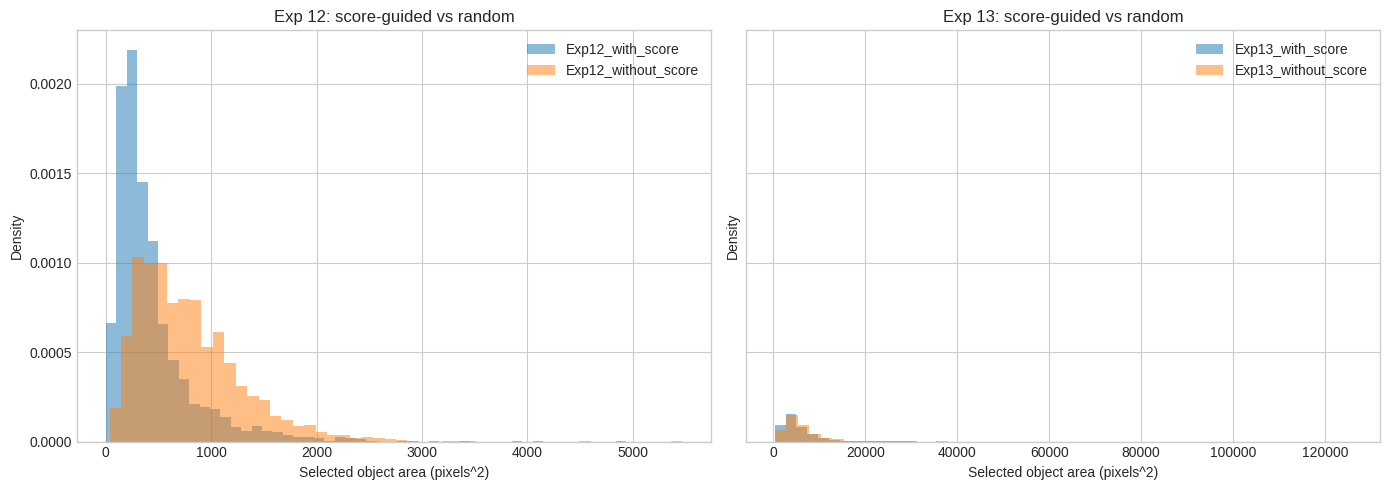

In [16]:
# Side-by-side histograms for Exp12 and Exp13
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

bins = 50

for ax, df, title in [
    (axes[0], exp12_df, "Exp 12: score-guided vs random"),
    (axes[1], exp13_df, "Exp 13: score-guided vs random"),
]:
    for group in sorted(df["group"].unique()):
        areas = df.loc[df["group"] == group, "area_px"].to_numpy()
        ax.hist(areas, bins=bins, alpha=0.5, label=group, density=True)

    ax.set_title(title)
    ax.set_xlabel("Selected object area (pixels^2)")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

In [17]:
# Exp 19: alpha sweep comparison
exp19_a1 = extract_selected_areas(list_metadata_files(EXP19_ROOT, "alpha_1p0"), "alpha_1")
exp19_a3 = extract_selected_areas(list_metadata_files(EXP19_ROOT, "alpha_3p0"), "alpha_3")
exp19_a5 = extract_selected_areas(list_metadata_files(EXP19_ROOT, "alpha_5p0"), "alpha_5")

exp19_df = pd.concat([exp19_a1, exp19_a3, exp19_a5], ignore_index=True)
print("Exp19 object rows:", len(exp19_df))

Exp19 object rows: 23085


In [18]:
exp19_summary = summarize_areas(exp19_df)
display(exp19_summary)

,group,n_objects,mean_area,median_area,frac_area_lt_1024,frac_area_lt_256,n_seeds,n_metadata_files
0,alpha_1,7810,550.2214,432.0008,0.8848,0.2478,3,1608
1,alpha_3,7700,403.2512,293.9888,0.9395,0.4274,3,1608
2,alpha_5,7575,388.5715,271.9987,0.9368,0.4738,3,1608


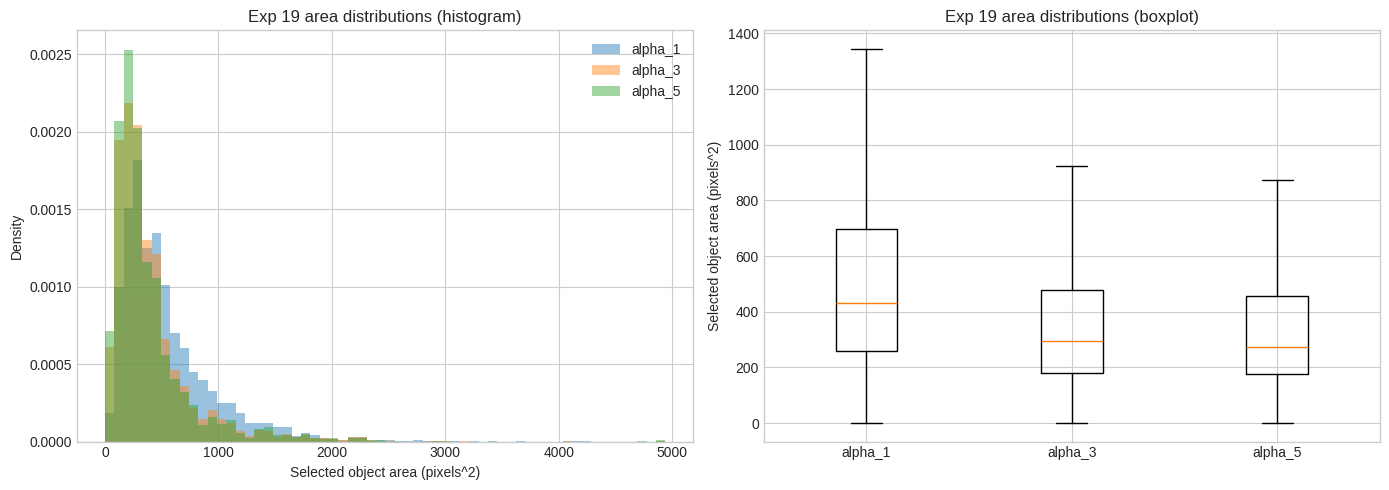

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for group in ["alpha_1", "alpha_3", "alpha_5"]:
    arr = exp19_df.loc[exp19_df["group"] == group, "area_px"].to_numpy()
    axes[0].hist(arr, bins=60, alpha=0.45, density=True, label=group)

axes[0].set_title("Exp 19 area distributions (histogram)")
axes[0].set_xlabel("Selected object area (pixels^2)")
axes[0].set_ylabel("Density")
axes[0].legend()

box_data = [
    exp19_df.loc[exp19_df["group"] == "alpha_1", "area_px"].to_numpy(),
    exp19_df.loc[exp19_df["group"] == "alpha_3", "area_px"].to_numpy(),
    exp19_df.loc[exp19_df["group"] == "alpha_5", "area_px"].to_numpy(),
]
axes[1].boxplot(box_data, tick_labels=["alpha_1", "alpha_3", "alpha_5"], showfliers=False)
axes[1].set_title("Exp 19 area distributions (boxplot)")
axes[1].set_ylabel("Selected object area (pixels^2)")

plt.tight_layout()
plt.show()

In [20]:
# Quick expectation check: alpha_5 should prefer smaller objects
pivot = exp19_summary.set_index("group")[ ["median_area", "frac_area_lt_1024", "frac_area_lt_256"] ]
display(pivot)

if {"alpha_1", "alpha_5"}.issubset(set(pivot.index)):
    median_smaller = pivot.loc["alpha_5", "median_area"] < pivot.loc["alpha_1", "median_area"]
    frac1024_larger = pivot.loc["alpha_5", "frac_area_lt_1024"] > pivot.loc["alpha_1", "frac_area_lt_1024"]
    frac256_larger = pivot.loc["alpha_5", "frac_area_lt_256"] > pivot.loc["alpha_1", "frac_area_lt_256"]

    print("alpha_5 median area < alpha_1 median area:", median_smaller)
    print("alpha_5 frac(area<1024) > alpha_1:", frac1024_larger)
    print("alpha_5 frac(area<256) > alpha_1:", frac256_larger)
else:
    print("Missing alpha_1 or alpha_5 rows in summary.")

,median_area,frac_area_lt_1024,frac_area_lt_256
group,,,
alpha_1,432.0008,0.8848,0.2478
alpha_3,293.9888,0.9395,0.4274
alpha_5,271.9987,0.9368,0.4738


alpha_5 median area < alpha_1 median area: True
alpha_5 frac(area<1024) > alpha_1: True
alpha_5 frac(area<256) > alpha_1: True
